# Titanic Mini Exploratory Data Analysis (EDA)

## Task 3









# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. Load Dataset

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Explore Dataset

In [3]:
print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())

Shape: (891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 4. Data Cleaning

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# 5. Feature Engineering

In [5]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

df['FamilySize'] = df['SibSp'] + df['Parch']

# 6. Survival Rate by Age Group

In [6]:
survival_by_age = df.groupby('AgeGroup')['Survived'].mean()
print(survival_by_age)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_5189/2916928670.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean()


# 7. Survival Rate by Embarkation Port

In [7]:
survival_by_port = df.groupby('Embarked')['Survived'].mean()
print(survival_by_port)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


# 8. Survival Rate by Family Size

In [8]:
survival_by_family = df.groupby('FamilySize')['Survived'].mean()
print(survival_by_family)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


# 9. Age Distribution Histogram

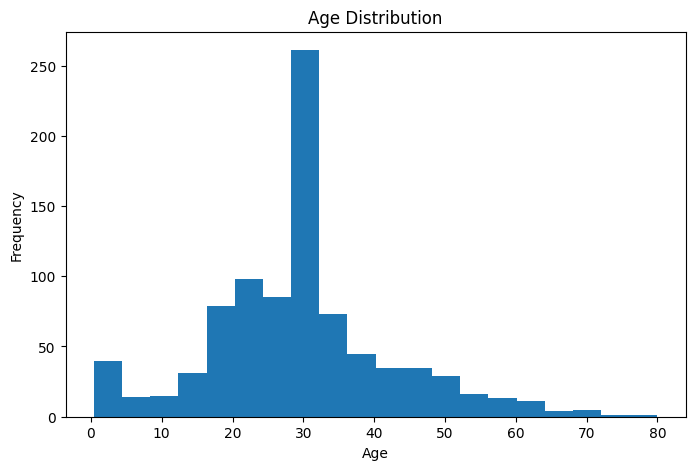

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 10. Correlation Heatmap

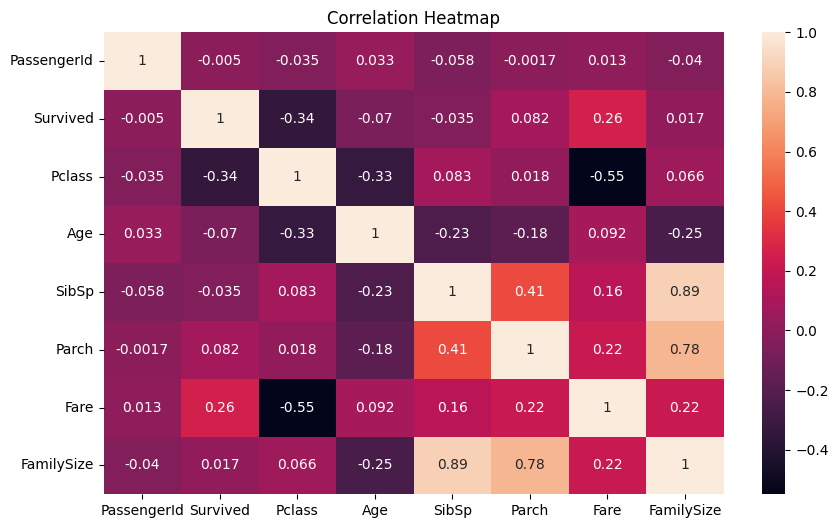

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

# 11. Survival by Family Size

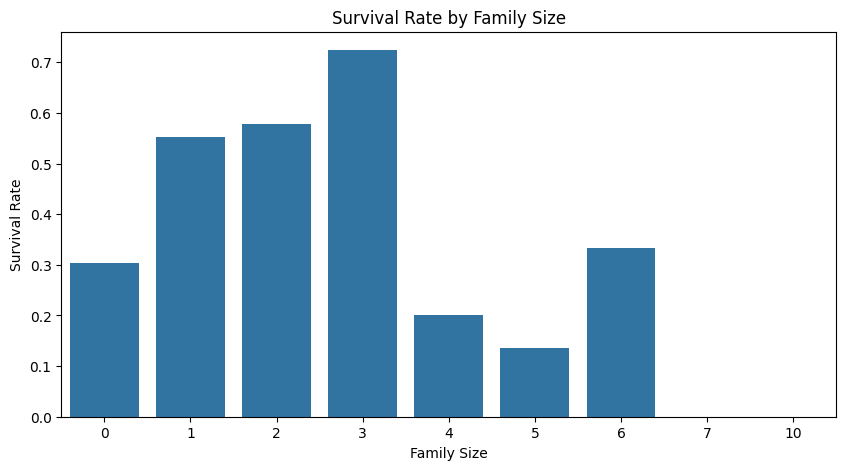

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x=survival_by_family.index, y=survival_by_family.values)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

## 12. Insights and Conclusion

### Key Findings from EDA:

*   **Data Cleaning**: Missing values in 'Age' were imputed with the mean, 'Cabin' column was dropped due to a high number of missing values, and missing values in 'Embarked' were filled with the mode.
*   **Age Distribution**: The age distribution histogram shows a concentration of passengers in younger adult ages.
*   **Survival by Age Group**: Children (0-12 years) had the highest survival rate, indicating that policies prioritizing children were effective. Young adults (18-35) had the lowest survival rate, while seniors (60+) also had a notably low survival rate.
*   **Survival by Embarkation Port**: Passengers who embarked from Cherbourg ('C') had a significantly higher survival rate compared to those from Queenstown ('Q') and Southampton ('S'). This could be due to differences in passenger class or other factors related to the embarkation port.
*   **Survival by Family Size**: Passengers traveling with a small to medium family size (1 to 3 members including themselves) had higher survival rates. Those traveling alone (FamilySize = 0) or with very large families (FamilySize > 3) had lower survival chances, suggesting that a moderate family size might have offered an advantage in survival.
*   **Correlation Heatmap**: (Assuming correlation values from `numeric_df.corr()` would be visible after execution)
    *   `Pclass` likely shows a negative correlation with `Survived`, suggesting lower class passengers had lower survival rates.
    *   `Fare` likely shows a positive correlation with `Survived`, indicating higher fare passengers had better survival chances.
    *   `Age` might show a slight negative correlation with `Survived`, supporting the finding that older individuals had lower survival rates.

### Conclusion:

This mini EDA reveals several critical factors influencing survival on the Titanic, including age, embarkation point, and family size. These insights can be used to inform further predictive modeling or to understand the demographics of survivors versus non-survivors. The dataset is clean and preprocessed for further analysis.